# **1. Import Library**


In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **2. Load Dataset**

### **Konteks**

Dalam industri E-commerce yang sangat kompetitif, mempertahankan pelanggan yang sudah ada lima kali lebih murah daripada mendapatkan pelanggan baru. Dataset ini mensimulasikan pola perilaku 15.000 pelanggan selama periode pengamatan 3 bulan. Dataset ini dirancang khusus untuk membantu Ilmuwan Data membangun model prediktif yang dapat mengidentifikasi pelanggan **"berisiko"** sebelum mereka meninggalkan platform.

### **Konten**

Dataset ini menangkap fenomena **"Engagement Decay"**. Dataset ini mencakup:

- **`User Engagement`**: Frekuensi login bulanan dan durasi penggunaan aplikasi.

- **`Financial Metrics`**: Pengeluaran bulanan dan sensitivitas terhadap diskon.

- **`Customer Friction`**: Frekuensi panggilan dukungan dan skor kepuasan keseluruhan.

- **`Contractual Data`**: Durasi berlangganan dan jenis kontrak (Bulanan vs. Tahunan).

### **Wawasan Utama**

Data tidak seimbang (tingkat churn sekitar 9,5%), yang mencerminkan skenario dunia nyata di mana churn merupakan kelas minoritas. Ini memberikan kesempatan yang sangat baik untuk mempraktikkan teknik seperti **SMOTE**, **Random UnderSampling**, atau menyesuaikan **Class Weights** dalam model pembelajaran mesin.


In [3]:
# Load dataset
data = pd.read_csv("../data/raw/ecommerce_customer_churn_data.csv")

# **3. EDA dan XDA**


### **A. Overview Data**


In [4]:
# Cek dimensi dataframe (baris x kolom)
data.shape

(15000, 12)

In [5]:
#  Melihat sampling 5 baris teratas
data.head().T

,0,1,2,3,4
CustomerID,CUST-00001,CUST-00002,CUST-00003,CUST-00004,CUST-00005
Age,35,50,58,56,35
Subscription_Duration_Months,25,33,16,50,43
Contract_Type,Monthly,Annual,Monthly,Monthly,Monthly
Monthly_Logins,14,13,10,7,13
Last_Purchase_Days_Ago,16,27,11,3,14
App_Usage_Time_Min,9.0,26.1,30.5,18.5,27.7
Monthly_Spend,171.14,28.98,229.94,46.95,168.75
Discount_Usage_Percentage,0.1,0.33,0.33,0.15,0.32
Customer_Support_Calls,3,1,1,0,1


In [6]:
#  Menampilkan informasi ringkas dari data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CustomerID                    15000 non-null  object 
 1   Age                           15000 non-null  int64  
 2   Subscription_Duration_Months  15000 non-null  int64  
 3   Contract_Type                 15000 non-null  object 
 4   Monthly_Logins                15000 non-null  int64  
 5   Last_Purchase_Days_Ago        15000 non-null  int64  
 6   App_Usage_Time_Min            15000 non-null  float64
 7   Monthly_Spend                 15000 non-null  float64
 8   Discount_Usage_Percentage     15000 non-null  float64
 9   Customer_Support_Calls        15000 non-null  int64  
 10  Satisfaction_Score            15000 non-null  int64  
 11  Is_Churn                      15000 non-null  int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 1.4+ MB


In [7]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,15000.0,43.697800,15.041621,18.0,31.0000,44.000,57.0000,69.00
Subscription_Duration_Months,15000.0,30.394733,17.321135,1.0,15.0000,30.000,45.0000,60.00
Monthly_Logins,15000.0,11.996200,3.482996,1.0,10.0000,12.000,14.0000,28.00
Last_Purchase_Days_Ago,15000.0,14.640200,14.879383,0.0,4.0000,10.000,21.0000,90.00
App_Usage_Time_Min,15000.0,20.103120,9.738783,1.0,13.2000,20.000,26.8000,61.30
Monthly_Spend,15000.0,126.123014,121.271770,10.0,52.9675,91.295,156.5325,2000.00
Discount_Usage_Percentage,15000.0,0.285778,0.159259,0.0,0.1600,0.260,0.3900,0.89
Customer_Support_Calls,15000.0,1.509333,1.223552,0.0,1.0000,1.000,2.0000,8.00
Satisfaction_Score,15000.0,4.352267,0.677991,1.0,4.0000,4.000,5.0000,5.00
Is_Churn,15000.0,0.095533,0.293960,0.0,0.0000,0.000,0.0000,1.00


In [8]:
# Menampilkan isi kolom Is_Churn dengan unik
data["Is_Churn"].unique()

array([0, 1])

In [9]:
# Cek keseimbangan nilai Is_Churn
data["Is_Churn"].value_counts()

Is_Churn
0    13567
1     1433
Name: count, dtype: int64

In [10]:
# Cek prosentase nilai Is_Churn
data["Is_Churn"].value_counts(normalize=True)

Is_Churn
0    0.904467
1    0.095533
Name: proportion, dtype: float64

In [11]:
# Hitung cell kosong
data.isna().sum()

CustomerID                      0
Age                             0
Subscription_Duration_Months    0
Contract_Type                   0
Monthly_Logins                  0
Last_Purchase_Days_Ago          0
App_Usage_Time_Min              0
Monthly_Spend                   0
Discount_Usage_Percentage       0
Customer_Support_Calls          0
Satisfaction_Score              0
Is_Churn                        0
dtype: int64

### **B. Visualisasi Data**


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Subscription_Duration_Months'}>,
        <Axes: title={'center': 'Monthly_Logins'}>],
       [<Axes: title={'center': 'Last_Purchase_Days_Ago'}>,
        <Axes: title={'center': 'App_Usage_Time_Min'}>,
        <Axes: title={'center': 'Monthly_Spend'}>],
       [<Axes: title={'center': 'Discount_Usage_Percentage'}>,
        <Axes: title={'center': 'Customer_Support_Calls'}>,
        <Axes: title={'center': 'Satisfaction_Score'}>],
       [<Axes: title={'center': 'Is_Churn'}>, <Axes: >, <Axes: >]],
      dtype=object)

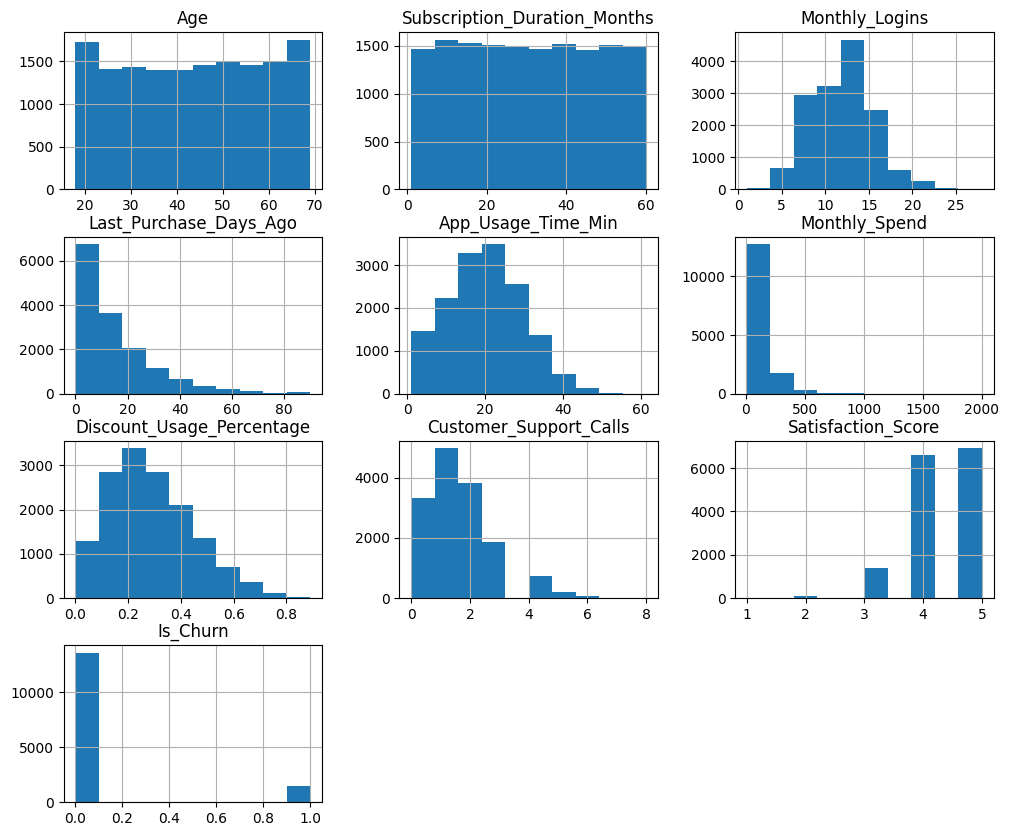

In [12]:
# Diagram garis
data.hist(figsize=(12, 10))

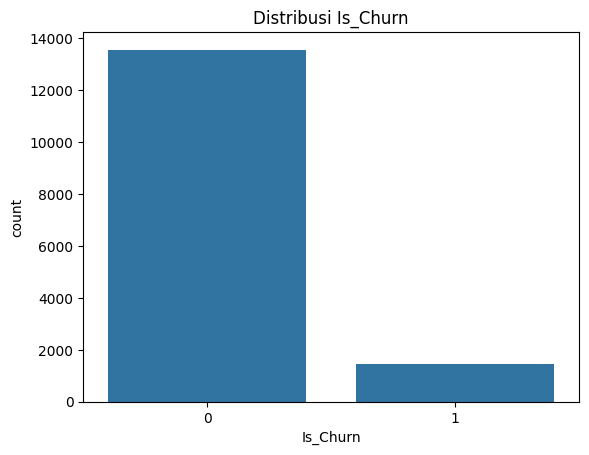

In [13]:
# Visualisasi kolom Is_Churn
sns.countplot(x="Is_Churn", data=data)
plt.title("Distribusi Is_Churn")
plt.show()

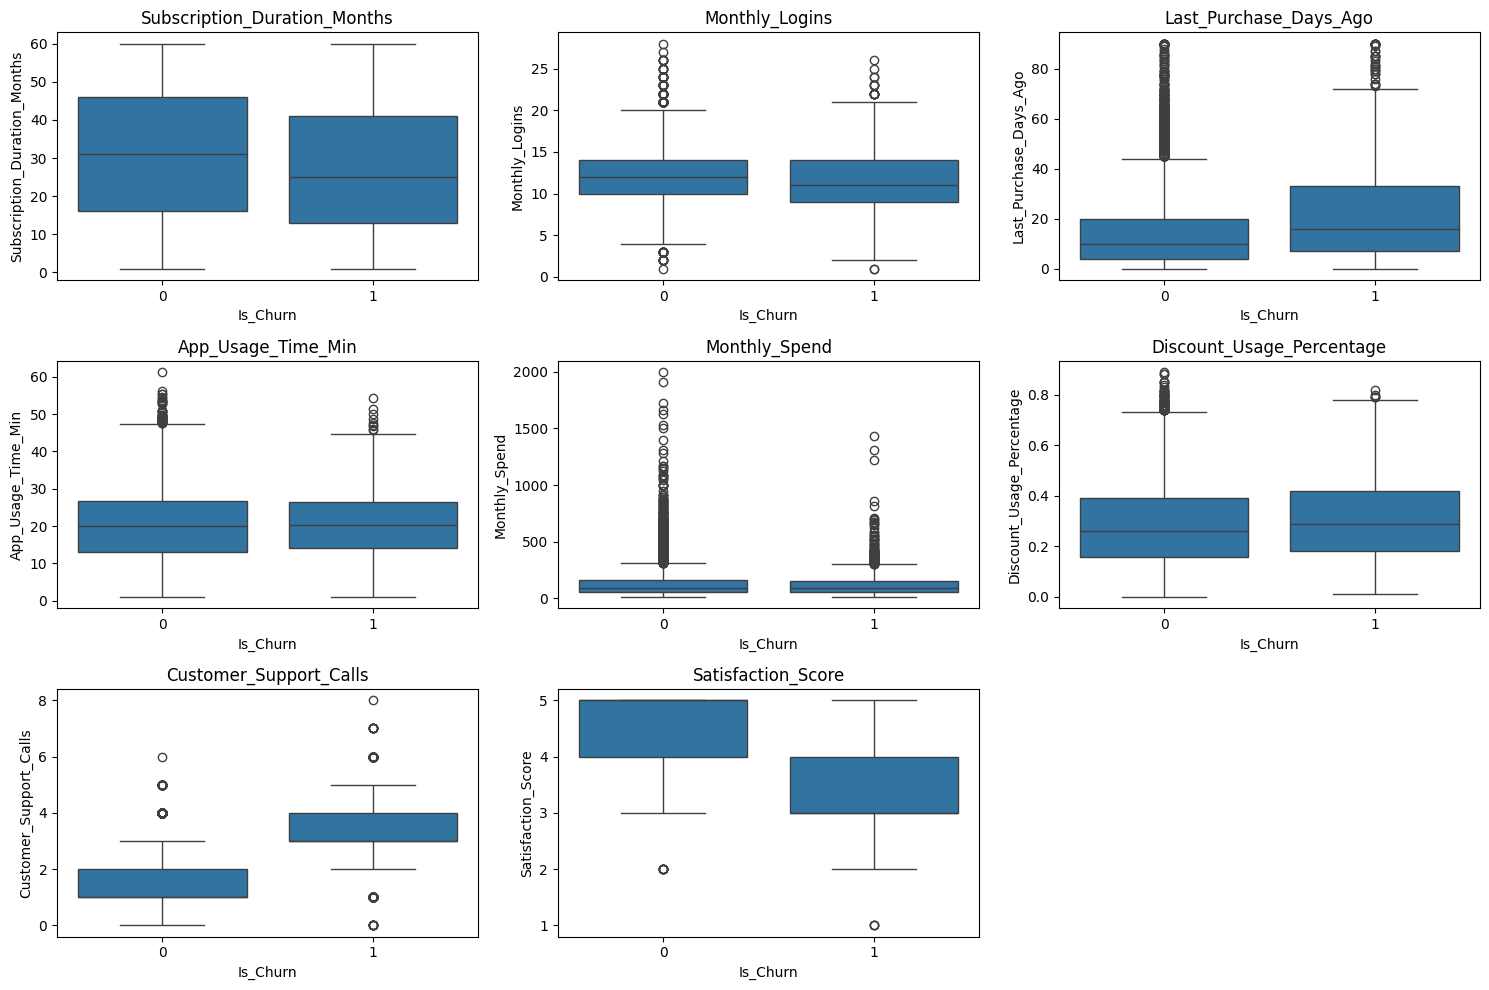

In [14]:
# Boxplot fitur numerik penting
cols = [
    "Subscription_Duration_Months",
    "Monthly_Logins",
    "Last_Purchase_Days_Ago",
    "App_Usage_Time_Min",
    "Monthly_Spend",
    "Discount_Usage_Percentage",
    "Customer_Support_Calls",
    "Satisfaction_Score",
]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="Is_Churn", y=col, data=data)
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
# Cek korelasi fitur vs target
data.corr(numeric_only=True)["Is_Churn"].sort_values(ascending=False)

Is_Churn                        1.000000
Customer_Support_Calls          0.484937
Last_Purchase_Days_Ago          0.161278
Discount_Usage_Percentage       0.044048
App_Usage_Time_Min              0.007169
Age                             0.005384
Monthly_Spend                  -0.004007
Monthly_Logins                 -0.038520
Subscription_Duration_Months   -0.063410
Satisfaction_Score             -0.442171
Name: Is_Churn, dtype: float64

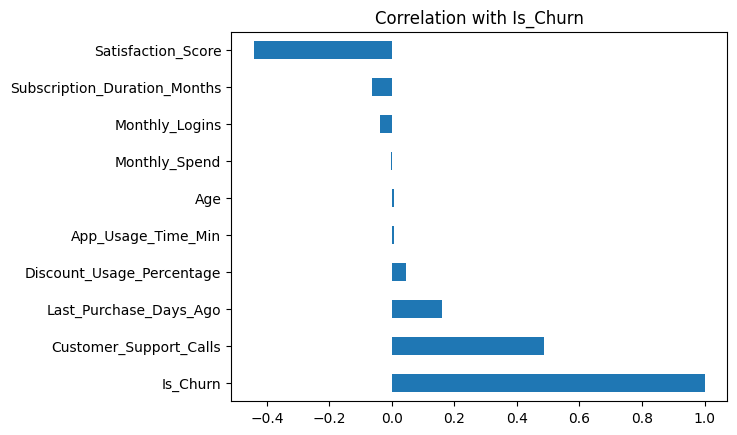

In [16]:
# Visualisasikan
corr_target = data.corr(numeric_only=True)["Is_Churn"].sort_values(ascending=False)

corr_target.plot(kind="barh")
plt.title("Correlation with Is_Churn")
plt.show()

_Kesimpulan sementara_

1. `Satisfaction_Score` berkorelasi _negatif_ sangat kuat dengan Churn
2. Begitu sebaliknya dengan `Customer_Support_Calls` dan `Last_Purchase_Days_Ago` berkorelasi kuat secara _positif_ dengan Churn. Artinya bila seorang pelanggan sering memanggil Customer Service atau terakhir bertransaksi sudah lama maka bisa diprediksi akan Churn.


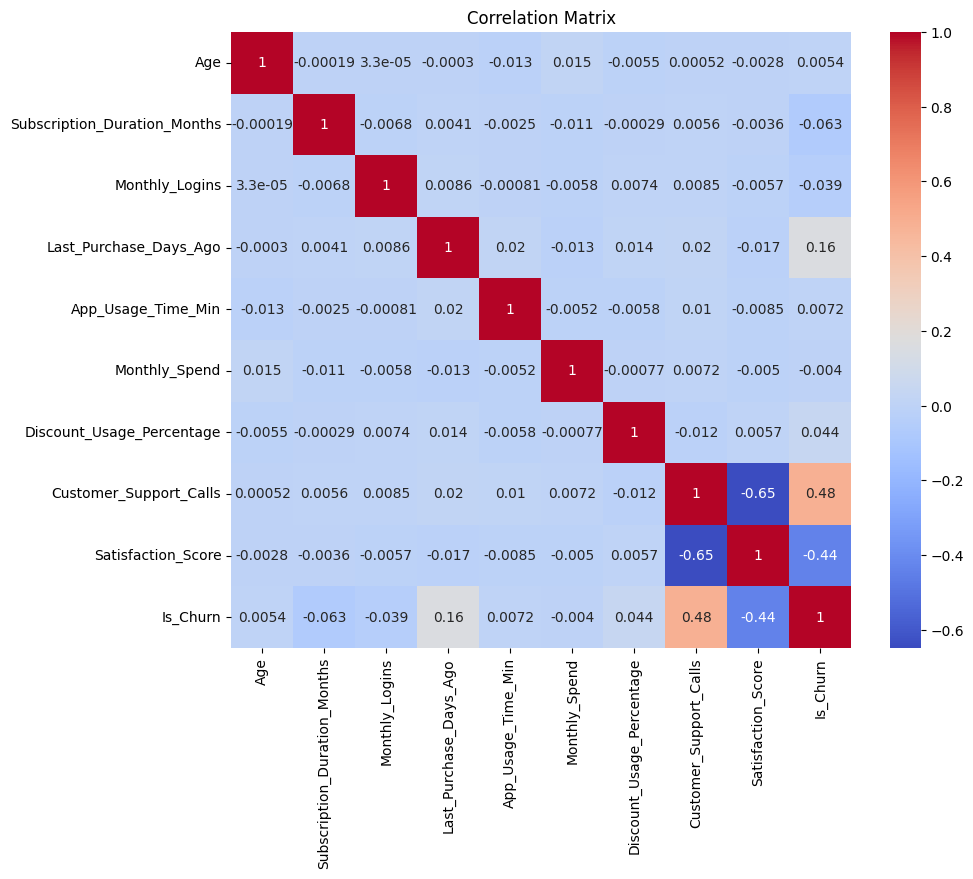

In [17]:
# Visualisasi korelasi antar fitur
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Cek korelasi crosstab data kategorikal dengan target
categorical_columns = data.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    print(f"\n=== {col} ===")
    print(pd.crosstab(data[col], data["Is_Churn"], normalize="index"))


=== CustomerID ===
Is_Churn      0    1
CustomerID          
CUST-00001  1.0  0.0
CUST-00002  1.0  0.0
CUST-00003  1.0  0.0
CUST-00004  1.0  0.0
CUST-00005  1.0  0.0
...         ...  ...
CUST-14996  1.0  0.0
CUST-14997  1.0  0.0
CUST-14998  1.0  0.0
CUST-14999  1.0  0.0
CUST-15000  0.0  1.0

[15000 rows x 2 columns]

=== Contract_Type ===
Is_Churn              0         1
Contract_Type                    
Annual         0.938405  0.061595
Monthly        0.881797  0.118203


### **C. Handling Missing Values**


In [21]:
# Melakukan drop pada kolom customerID karena tidak mempengaruhi hasil analisa

data.drop("CustomerID", axis=1, inplace=True)

In [22]:
# Cek kembali data Null
data.isnull().sum()

Age                             0
Subscription_Duration_Months    0
Contract_Type                   0
Monthly_Logins                  0
Last_Purchase_Days_Ago          0
App_Usage_Time_Min              0
Monthly_Spend                   0
Discount_Usage_Percentage       0
Customer_Support_Calls          0
Satisfaction_Score              0
Is_Churn                        0
dtype: int64

### **D. Handling Duplicates**


In [23]:
# Cek dataset duplikat

data.duplicated().sum()

0

### **E. Split Dataset**


In [25]:
data_train, data_test = train_test_split(
    data, test_size=0.05, random_state=42, shuffle=True
)
data_train.reset_index(drop=True, inplace=True)
data_test.reset_index(drop=True, inplace=True)

print(data_train.shape)
print(data_test.shape)

(14250, 11)
(750, 11)


In [26]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14250 entries, 0 to 14249
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           14250 non-null  int64  
 1   Subscription_Duration_Months  14250 non-null  int64  
 2   Contract_Type                 14250 non-null  object 
 3   Monthly_Logins                14250 non-null  int64  
 4   Last_Purchase_Days_Ago        14250 non-null  int64  
 5   App_Usage_Time_Min            14250 non-null  float64
 6   Monthly_Spend                 14250 non-null  float64
 7   Discount_Usage_Percentage     14250 non-null  float64
 8   Customer_Support_Calls        14250 non-null  int64  
 9   Satisfaction_Score            14250 non-null  int64  
 10  Is_Churn                      14250 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.2+ MB


In [27]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           750 non-null    int64  
 1   Subscription_Duration_Months  750 non-null    int64  
 2   Contract_Type                 750 non-null    object 
 3   Monthly_Logins                750 non-null    int64  
 4   Last_Purchase_Days_Ago        750 non-null    int64  
 5   App_Usage_Time_Min            750 non-null    float64
 6   Monthly_Spend                 750 non-null    float64
 7   Discount_Usage_Percentage     750 non-null    float64
 8   Customer_Support_Calls        750 non-null    int64  
 9   Satisfaction_Score            750 non-null    int64  
 10  Is_Churn                      750 non-null    int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 64.6+ KB


In [28]:
X_train = data_train.drop("Is_Churn", axis=1)
y_train = data_train["Is_Churn"]

In [29]:
X_test = data_test.drop("Is_Churn", axis=1)
y_test = data_test["Is_Churn"]

### **F. Scalling & Encoding Data**


In [51]:
# Tentukan kolom numerik
numerical_columns = [
    "Age",
    "Subscription_Duration_Months",
    "Monthly_Logins",
    "Last_Purchase_Days_Ago",
    "App_Usage_Time_Min",
    "Monthly_Spend",
    "Discount_Usage_Percentage",
    "Customer_Support_Calls",
    "Satisfaction_Score",
]
os.makedirs("../models", exist_ok=True)

# Tentukan Scaler yang dipakai
numeric_transformer = MinMaxScaler()

In [ ]:
# Tentukan kolom kategorikal
from sklearn.decomposition import sparse_encode

categorical_columns = [
    "Contract_Type",
]

# Tentukan encoder yang dipakai
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numerical_columns),
        ("categoric", categorical_transformer, categorical_columns),
    ]
)

In [37]:
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])
X_train_clean = pipeline.fit_transform(X_train)
X_test_clean = pipeline.transform(X_test)

In [38]:
# kolom hasil OneHotEncoder
cat_cols = (
    pipeline.named_steps["preprocessor"]
    .named_transformers_["categoric"]
    .get_feature_names_out(categorical_columns)
)

In [39]:
# gabungkan semua kolom
all_columns = numerical_columns + list(cat_cols)

In [40]:
# Rubah ke dataframe
data_train_clean = pd.DataFrame(X_train_clean, columns=all_columns)
data_test_clean = pd.DataFrame(X_test_clean, columns=all_columns)

In [41]:
# Masukkan kembali kolom Is_Churn ke masing - masing dataframe yang bersesuain
data_train_clean["Is_Churn"] = y_train.reset_index(drop=True)
data_test_clean["Is_Churn"] = y_test.reset_index(drop=True)

In [42]:
data_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14250 entries, 0 to 14249
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           14250 non-null  float64
 1   Subscription_Duration_Months  14250 non-null  float64
 2   Monthly_Logins                14250 non-null  float64
 3   Last_Purchase_Days_Ago        14250 non-null  float64
 4   App_Usage_Time_Min            14250 non-null  float64
 5   Monthly_Spend                 14250 non-null  float64
 6   Discount_Usage_Percentage     14250 non-null  float64
 7   Customer_Support_Calls        14250 non-null  float64
 8   Satisfaction_Score            14250 non-null  float64
 9   Contract_Type_Annual          14250 non-null  float64
 10  Contract_Type_Monthly         14250 non-null  float64
 11  Is_Churn                      14250 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.3 MB


In [43]:
data_test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           750 non-null    float64
 1   Subscription_Duration_Months  750 non-null    float64
 2   Monthly_Logins                750 non-null    float64
 3   Last_Purchase_Days_Ago        750 non-null    float64
 4   App_Usage_Time_Min            750 non-null    float64
 5   Monthly_Spend                 750 non-null    float64
 6   Discount_Usage_Percentage     750 non-null    float64
 7   Customer_Support_Calls        750 non-null    float64
 8   Satisfaction_Score            750 non-null    float64
 9   Contract_Type_Annual          750 non-null    float64
 10  Contract_Type_Monthly         750 non-null    float64
 11  Is_Churn                      750 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 70.4 KB


In [44]:
# Pastikan kolom sama
set(data_train_clean.columns) == set(data_test_clean.columns)

True

### **G. Save File Processed**


In [45]:
# Ekspor train
data_train_clean.to_csv("../data/processed/train_processed.csv", index=False)

In [46]:
# Ekspor test
data_test_clean.to_csv("../data/processed/test_processed.csv", index=False)

### **H. Save Pipeline ke Joblib**


In [50]:
joblib.dump(pipeline, "../models/preprocessing_pipeline.pkl")

['../models/preprocessing_pipeline.pkl']